# 03 Label construction

**Purpose:** build the targets the models will learn from. Neither Task 1 target is given directly, so we derive them from the route legs. Task 2A also needs a weekly demand table built to Waypoint's counting rules.

**Inputs:** clean tables from notebook 02 (`data/processed/`).

**Outputs** (in `data/processed/`):
- `stops.parquet`: one row per dispatched order (train and test) joined to its route leg, with the two Task 1 labels filled in for train
- `weekly_demand.parquet`: weekly total and chilled volume per depot and brand, ready for Task 2A

**The labels in one line each**
- `service_min` = time the vehicle leaves the outlet minus the later of its arrival and the window opening
- `late` = 1 if the vehicle arrives after the window closes, else 0

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xora.io import load_processed, save_processed
from xora.plotting import apply_style, SERIES
from xora import checks as ck

apply_style()
pd.set_option("display.width", 160)

orders = load_processed("orders")
legs = load_processed("legs")
outlets = load_processed("outlets")
calendar = load_processed("calendar")
allowance = load_processed("service_allowance")

## 1. One row per delivered order

Notebook 01 showed that every dispatched order, deferred ones included, has exactly one route leg. We join on route and stop position, and keep only the leg columns the labels and later features need.

In [2]:
LEG_COLS = [
    "route_id", "seq", "leg_id", "date", "from_point", "distance_km", "dow", "monsoon",
    "planned_depart_time_min", "planned_travel_duration_min", "planned_arrival_time_min",
    "actual_depart_time_min", "actual_travel_duration_min", "arrival_time_min", "leave_outlet_time_min",
]

dispatched = orders[orders.route_id.notna()]
stops = dispatched.merge(
    legs[LEG_COLS], left_on=["route_id", "seq_in_route"], right_on=["route_id", "seq"],
    how="left", validate="one_to_one",
).merge(outlets[["outlet_id", "dock_type", "parking_constraint"]], on="outlet_id", how="left", validate="many_to_one")

stops.groupby("split").size().rename("stops").to_frame()

,stops
split,
test,5014
train,91894


`validate="one_to_one"` makes pandas raise an error if any order matched more than one leg, so the join is checked by construction. The `not_run` orders drop out here because they never had a route. They come back in section 5 for the demand table.

## 2. Service time label

**Why not simply leave time minus arrival time?** Waypoint's rules say outlets receive goods only within their window and early arrivals wait until it opens. Time spent waiting outside a closed outlet is not handling time. So service starts at whichever comes later: the arrival or the window opening.

```
service_start = max(arrival_time, window_open_time)
service_min   = leave_outlet_time - service_start
wait_min      = service_start - arrival_time      (0 when the vehicle arrives inside the window)
```

In [3]:
train = stops.split == "train"

service_start = np.maximum(stops.arrival_time_min, stops.window_open_time_min)
stops["wait_min"] = (service_start - stops.arrival_time_min).where(train)
stops["service_min"] = (stops.leave_outlet_time_min - service_start).where(train)
stops["dwell_min"] = (stops.leave_outlet_time_min - stops.arrival_time_min).where(train)

stops.loc[train, ["dwell_min", "wait_min", "service_min"]].describe().round(1).T

,count,mean,std,min,25%,50%,75%,max
dwell_min,91894.0,19.9,15.7,2.0,11.0,16.0,23.0,428.0
wait_min,91894.0,0.9,5.7,0.0,0.0,0.0,0.0,132.0
service_min,91894.0,19.0,14.9,2.0,11.0,15.0,22.0,428.0


In [4]:
waited = stops.loc[train & (stops.wait_min > 0)]
pd.Series({
    "stops that waited for the window": len(waited),
    "share of all stops": round(len(waited) / train.sum(), 3),
    "median wait when waiting (min)": waited.wait_min.median(),
    "share of waits on the first stop": round((waited.seq == 0).mean(), 3),
})

stops that waited for the window    4023.000
share of all stops                     0.044
median wait when waiting (min)        14.000
share of waits on the first stop       0.730
dtype: float64

Waiting is rare overall but concentrated on first stops, where a truck that left the depot early reaches an outlet before it opens. Using leave minus arrival would have inflated exactly those labels and taught the model that first stops are slow.

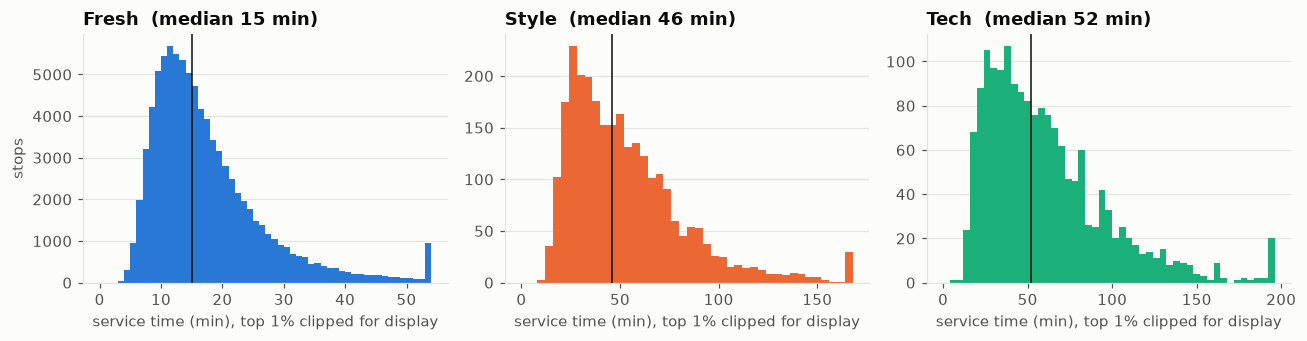

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))
for ax, brand, color in zip(axes, ["Fresh", "Style", "Tech"], SERIES):
    s = stops.loc[train & (stops.brand == brand), "service_min"]
    cap = s.quantile(0.99)
    width = 1 if brand == "Fresh" else 4  # times are whole minutes, so bins must be too
    ax.hist(s.clip(upper=cap), bins=np.arange(0, cap + width, width), color=color)
    ax.axvline(s.median(), color="#0b0b0b", linewidth=1)
    ax.set_title(f"{brand}  (median {s.median():.0f} min)")
    ax.set_xlabel("service time (min), top 1% clipped for display")
axes[0].set_ylabel("stops")
plt.tight_layout()
plt.show()

In [6]:
stops.loc[train].pivot_table(index="brand", columns="dock_type", values="service_min", aggfunc="median")

dock_type,mall_bay,rear_dock,street
brand,,,
Fresh,NaN,15.0,14.0
Style,61.0,30.0,45.0
Tech,74.0,35.0,67.0


Service time differs a lot by brand and by how goods come off the truck: rear docks are quickest, and mall bays are slowest for Style and Tech. The distributions are right-skewed, with a long tail of slow stops. Those are kept, as explained in notebook 02.

## 3. Late label

Waypoint defines late as arriving after `window_close_time`. Late deliveries are still made, so this label is about arrival only, not about whether the order was delivered.

```
late = 1 if arrival_time > window_close_time else 0
```

Arriving exactly at closing time counts as on time, because the operating rules say "after".

In [7]:
stops["late"] = (stops.arrival_time_min > stops.window_close_time_min).astype("Int8").where(train)
stops["late_by_min"] = (stops.arrival_time_min - stops.window_close_time_min).clip(lower=0).where(train)

pd.Series({
    "late rate": stops.loc[train, "late"].mean().round(3),
    "arrivals exactly at closing time (counted on time)": int((stops.arrival_time_min == stops.window_close_time_min)[train].sum()),
    "median minutes late, when late": stops.loc[train & (stops.late == 1), "late_by_min"].median(),
})

late rate                                               0.196
arrivals exactly at closing time (counted on time)    279.000
median minutes late, when late                         48.000
dtype: float64

In [8]:
stops.loc[train].groupby(["brand", "depot"]).late.agg(late_rate="mean", stops="size").round(3)

late_rate  stops
brand depot                       
Fresh Kandy           0.202  34039
      Peliyagoda      0.205  53418
Style Kandy           0.035    977
      Peliyagoda      0.066   1756
Tech  Kandy           0.064    593
      Peliyagoda      0.004   1111

About one stop in five arrives late, mostly Fresh, where the window closes around 8 AM and routes are long. Classes are imbalanced but not extreme, so a plain probability model with good calibration is appropriate. No resampling is needed.

## 4. Proving the labels

A label is only as good as the times it is built from, so we check the three facts it relies on, plus the basic sanity of the result.

In [9]:
t = stops[train].sort_values(["route_id", "seq"])
next_depart = legs[legs.split == "train"].sort_values(["route_id", "seq"]).groupby("route_id").actual_depart_time_min.shift(-1).to_numpy()
arrival_gap = t.arrival_time_min - (t.actual_depart_time_min + t.actual_travel_duration_min)

proofs = ck.report([
    ck.check("every dispatched train order has exactly one leg", t.leg_id.isna().sum(), len(t)),
    ck.check("leave time equals the next leg's departure", ((next_depart == next_depart) & (next_depart != t.leave_outlet_time_min.to_numpy())).sum(), len(t),
             "so leave_outlet_time is a real event, not an estimate"),
    ck.check("arrival = departure + travel, within 1 minute rounding", (arrival_gap.abs() > 1).sum(), len(t)),
    ck.check("service time is positive", (t.service_min <= 0).sum(), len(t)),
    ck.check("wait is never negative", (t.wait_min < 0).sum(), len(t)),
    ck.check("every train stop has both labels", t[["service_min", "late"]].isna().any(axis=1).sum(), len(t)),
    ck.check("test stops have no labels (no leakage of actuals)", stops.loc[~train, ["service_min", "late"]].notna().any(axis=1).sum(), (~train).sum()),
])
proofs

,check,passed,failing_rows,total_rows,note
0,every dispatched train order has exactly one leg,True,0,91894,
1,leave time equals the next leg's departure,True,0,91894,"so leave_outlet_time is a real event, not an e..."
2,"arrival = departure + travel, within 1 minute ...",True,0,91894,
3,service time is positive,True,0,91894,
4,wait is never negative,True,0,91894,
5,every train stop has both labels,True,0,91894,
6,test stops have no labels (no leakage of actuals),True,0,5014,


### How good is today's planning standard?

Waypoint plans with a fixed allowance per brand and dock type (`service_allowance.csv`). Comparing it with the label gives the baseline our service-time model has to beat.

In [10]:
with_allowance = stops[train].merge(allowance, on=["brand", "dock_type"], how="left", validate="many_to_one")
err = with_allowance.service_min - with_allowance.service_allowance_min

baseline = with_allowance.assign(err=err).groupby("brand").err.agg(
    mae=lambda e: e.abs().mean(), bias="mean", share_over_by_10_min=lambda e: (e > 10).mean()
)
baseline.loc["all"] = [err.abs().mean(), err.mean(), (err > 10).mean()]
baseline.round(2)

,mae,bias,share_over_by_10_min
brand,,,
Fresh,6.73,1.83,0.14
Style,19.62,3.79,0.30
Tech,24.89,11.28,0.40
all,7.45,2.06,0.15


The allowance table is off by several minutes per stop on average and is badly off for Tech, where it also runs too low. This is the "before" number for Task 1.

## 5. Weekly demand table for Task 2A

The table follows three rules:
1. Count every order once, including deferred and never-dispatched (`not_run`) orders.
2. Assign each order to the week of its requested order date, not its dispatch date.
3. Group by `iso_year` and `iso_week` from `calendar.csv`.

Training orders cover ISO weeks up to 2026 week 7. The Task 1 test inputs cover weeks 8 to 13 and are the natural source for that gap. Task 2A then forecasts weeks 14 to 23.

In [11]:
orders_wk = orders.merge(calendar[["date", "iso_year", "iso_week"]], left_on="order_date", right_on="date", how="left", validate="many_to_one")
orders_wk["chilled_volume_m3"] = orders_wk.order_volume_m3.where(orders_wk.temp_requirement == "chilled", 0.0)

weekly = (
    orders_wk.groupby(["depot", "brand", "iso_year", "iso_week"])
    .agg(
        total_volume_m3=("order_volume_m3", "sum"),
        chilled_volume_m3=("chilled_volume_m3", "sum"),
        orders=("delivery_id", "size"),
        source=("split", lambda s: "test inputs" if (s == "test").all() else "train"),
    )
    .reset_index()
)
weekly.assign(year_week=weekly.iso_year.astype(str) + "-W" + weekly.iso_week.astype(str).str.zfill(2)).groupby("source").agg(
    series_weeks=("year_week", "size"), first_week=("year_week", "min"), last_week=("year_week", "max")
)

,series_weeks,first_week,last_week
source,,,
test inputs,36,2026-W08,2026-W13
train,666,2024-W01,2026-W07


### Adjusting the test weeks for missing `not_run` orders

Rule 1 says to count orders that were never dispatched, but the test inputs contain none (notebook 02). Leaving this alone would make weeks 8 to 13 look slightly lower than they really were, right where the forecast starts.

We estimate the missing volume from training. For each depot, brand and temperature, we take the volume of `not_run` orders as a share of all other orders, then scale up the test weeks by that share. The adjustment is small, so the raw totals are kept next to the adjusted ones.

In [12]:
hist = orders_wk[orders_wk.split == "train"]
key = ["depot", "brand", "temp_requirement"]
not_run_vol = hist[hist.dispatch_status == "not_run"].groupby(key).order_volume_m3.sum()
other_vol = hist[hist.dispatch_status != "not_run"].groupby(key).order_volume_m3.sum()
uplift = (not_run_vol / other_vol).reindex(other_vol.index, fill_value=0.0).rename("not_run_uplift")

uplift.unstack("temp_requirement").fillna(0).round(4)

temp_requirement  ambient  chilled
depot      brand                  
Kandy      Fresh   0.0003   0.0000
           Style   0.0136   0.0000
           Tech    0.0265   0.0000
Peliyagoda Fresh   0.0000   0.0168
           Style   0.0000   0.0000
           Tech    0.0000   0.0000

`not_run` orders are not spread evenly. Almost all are Peliyagoda chilled Fresh orders, which fits a shortage of refrigerated capacity there, plus a handful of large Style and Tech orders at Kandy. Using each group's long-run share gives the expected missing volume for a typical week, which is the best estimate we have without the actual orders.

In [13]:
test_wk = orders_wk[orders_wk.split == "test"].merge(uplift.reset_index(), on=key, how="left")
test_wk["extra_m3"] = test_wk.order_volume_m3 * test_wk.not_run_uplift
extra = test_wk.groupby(["depot", "brand", "iso_year", "iso_week"]).agg(
    extra_total_m3=("extra_m3", "sum"),
    extra_chilled_m3=("extra_m3", lambda s: s[test_wk.loc[s.index, "temp_requirement"] == "chilled"].sum()),
)

weekly = weekly.merge(extra.reset_index(), on=["depot", "brand", "iso_year", "iso_week"], how="left").fillna({"extra_total_m3": 0.0, "extra_chilled_m3": 0.0})
weekly["total_volume_m3_adj"] = weekly.total_volume_m3 + weekly.extra_total_m3
weekly["chilled_volume_m3_adj"] = weekly.chilled_volume_m3 + weekly.extra_chilled_m3
weekly = weekly.drop(columns=["extra_total_m3", "extra_chilled_m3"])

weekly[weekly.source == "test inputs"].groupby(["depot", "brand"])[["total_volume_m3", "total_volume_m3_adj"]].sum().assign(
    added_pct=lambda d: (d.total_volume_m3_adj / d.total_volume_m3 - 1) * 100
).round(2)

total_volume_m3  total_volume_m3_adj  added_pct
depot      brand                                                 
Kandy      Fresh          3140.23              3140.82       0.02
           Style           505.81               512.67       1.36
           Tech            118.22               121.35       2.65
Peliyagoda Fresh          5926.43              5962.60       0.61
           Style           898.31               898.31       0.00
           Tech            178.33               178.33       0.00

Checks on the finished table: every series has every week with no gaps, Style and Tech have no chilled volume (neither brand carries chilled goods), and the totals reconcile with the raw orders.

In [14]:
weeks_in_calendar = calendar[calendar.date <= orders.order_date.max()].drop_duplicates(["iso_year", "iso_week"]).shape[0]
per_series = weekly.groupby(["depot", "brand"]).size()

ck.report([
    ck.check("every depot and brand has every week", (per_series != weeks_in_calendar).sum(), len(per_series),
             f"{weeks_in_calendar} weeks per series"),
    ck.check("Style and Tech have zero chilled volume", (weekly.loc[weekly.brand != "Fresh", "chilled_volume_m3_adj"] != 0).sum(), (weekly.brand != "Fresh").sum()),
    ck.check("chilled never exceeds total", (weekly.chilled_volume_m3_adj > weekly.total_volume_m3_adj + 1e-9).sum(), len(weekly)),
    ck.check("raw weekly totals add up to the raw orders", int(abs(weekly.total_volume_m3.sum() - orders.order_volume_m3.sum()) > 1e-6), 1),
    ck.check("each order counted once", int(weekly.orders.sum() != len(orders)), 1),
])

,check,passed,failing_rows,total_rows,note
0,every depot and brand has every week,True,0,6,117 weeks per series
1,Style and Tech have zero chilled volume,True,0,468,
2,chilled never exceeds total,True,0,702,
3,raw weekly totals add up to the raw orders,True,0,1,
4,each order counted once,True,0,1,


In [15]:
weekly.tail(6)

,depot,brand,iso_year,iso_week,total_volume_m3,chilled_volume_m3,orders,source,total_volume_m3_adj,chilled_volume_m3_adj
696,Peliyagoda,Tech,2026,8,23.253,0.0,9,test inputs,23.253,0.0
697,Peliyagoda,Tech,2026,9,40.091,0.0,11,test inputs,40.091,0.0
698,Peliyagoda,Tech,2026,10,22.986,0.0,7,test inputs,22.986,0.0
699,Peliyagoda,Tech,2026,11,21.290,0.0,7,test inputs,21.290,0.0
700,Peliyagoda,Tech,2026,12,33.188,0.0,11,test inputs,33.188,0.0
701,Peliyagoda,Tech,2026,13,37.519,0.0,11,test inputs,37.519,0.0


## 6. Save and summarise

In [16]:
save_processed(stops, "stops")
save_processed(weekly, "weekly_demand")

pd.DataFrame({
    "rows": [len(stops), len(weekly)],
    "labelled rows": [int(stops.service_min.notna().sum()), len(weekly)],
}, index=["stops", "weekly_demand"])

,rows,labelled rows
stops,96908,91894
weekly_demand,702,702


**Label card**

| Label | Definition | Rows | Key numbers |
|---|---|---|---|
| `service_min` | leave time minus the later of arrival and window opening | every dispatched train order | Fresh median about 15 min, Style and Tech about 45 to 55 |
| `late` | arrival strictly after window close | every dispatched train order | about 20% late overall |
| `total_volume_m3_adj` | weekly order volume by order date and ISO week, test weeks adjusted for missing `not_run` orders | 6 series x every week | target for Task 2A |
| `chilled_volume_m3_adj` | chilled part of the above, 0 for Style and Tech | same | target for Task 2A |

**Decisions made here, and why**
- Waiting for the window to open is excluded from service time, because the operating rules say early arrivals wait.
- Deferred orders keep their labels, because they were really delivered (next day) and have real times.
- Long stops are kept, because they are real and the model must learn that delays happen.
- Test weeks are scaled up slightly for `not_run` orders, because they are real demand that the test inputs leave out.

Next: notebook 04 builds features and checks that each one would be known at the 4 PM order cutoff.